# Instant Model Experiments (Random Forest Classifier)

We load `instant_mock.csv`, pick the sensor features, and predict `comfortValue` classes.
We split into train/val/test and run a small grid search.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
data_path = '../../data/processed/instant_mock.csv'
df = pd.read_csv(data_path)

target_col = 'comfortValue'
feature_cols = ['humidity', 'light', 'temperature', 'noise', 'co2']

missing_cols = [col for col in [target_col] + feature_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df = df[feature_cols + [target_col]].dropna()

# Make sure the target is a clean class label
if pd.api.types.is_numeric_dtype(df[target_col]):
    df[target_col] = df[target_col].round().astype(int)

print(f"Rows after cleaning: {len(df):,}")
display(df.head())

Rows after cleaning: 1,812


,humidity,light,temperature,noise,co2,comfortValue
0,4225.0,7.669843,25.1,7.810250,0.001916,4
1,4225.0,7.669843,25.1,7.810250,0.001916,5
2,4096.0,6.835845,25.2,7.810250,0.001976,3
3,4096.0,6.835845,25.2,7.810250,0.001976,4
4,3969.0,7.039566,25.3,7.745967,0.001938,4


In [3]:
X = df[feature_cols]
y = df[target_col]

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=y,
    )

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=y_temp,
    )

print(f"Train size: {len(X_train):,}")
print(f"Val size:   {len(X_val):,}")
print(f"Test size:  {len(X_test):,}")

Train size: 1,268
Val size:   272
Test size:  272


In [4]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    )

grid = GridSearchCV(
    rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    )

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.3f}")

best_model = grid.best_estimator_

def eval_split(name, X_split, y_split):
    preds = best_model.predict(X_split)
    acc = accuracy_score(y_split, preds)
    print(f"{name} accuracy: {acc:.3f}")

eval_split("Validation", X_val, y_val)
eval_split("Test", X_test, y_test)

Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV accuracy: 0.352
Validation accuracy: 0.335
Test accuracy: 0.393


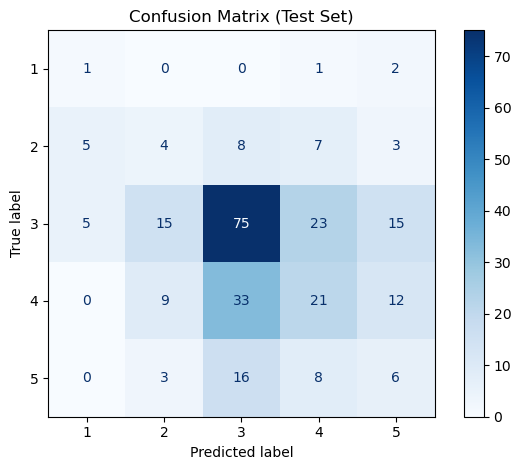

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_preds = best_model.predict(X_test)
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds,
    cmap='Blues',
    colorbar=True,
    )

plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()